In [19]:
import numpy as np
from scipy.optimize import minimize_scalar
import matplotlib.pyplot as plt
import json
from collections import defaultdict

In [29]:
def rescale_prob(model_probs: np.array, reference_probs: np.array) -> np.array:

    # input: model_probs: np.array(lists): each list is a pair of HT tokens [0.95, 0.05]; reference_probs: np.array(lists): each list is a pair of HT tokens [0.9, 0.1]; 
    def objective(temperature):
        total_tv = 0
        for i, model_prob_pair in enumerate(model_probs): 
            p=model_prob_pair ** (1.0/temperature) #scaled! 
            p=p/np.sum(p) # normalize! 
            q=reference_probs[i] 
            
            try: assert(np.sum(p)<1.05 and np.sum(p)>0.95)
            except: 
                print('sum(p): {}'.format(np.sum(p)))
                print(p, i, model_prob_pair)
            
            try: assert(np.sum(q)<1.05 and np.sum(q)>0.95)
            except: 
                print('sum(q): {}'.format(np.sum(q)))
                print(q, i, model_prob_pair)
            
            total_tv += 0.5*np.sum(np.abs(p-q))
        return total_tv
    res = minimize_scalar(objective, bounds=(0.0, 5), method='bounded')
    print(res.x)
    scaled = []
    for model_p in model_probs:
        scaled_p = model_p**(1.0/res.x)
        scaled.append(scaled_p/np.sum(scaled_p))
    # scaled = model_probs**(1.0/res.x)
    return scaled, res.fun

#### Log Probs

In [30]:
# Specify the file name
coinflip_p_path='/Users/nicolemeister/Desktop/STANFORD/distributions/data_analysis/data/'
file_name = coinflip_p_path+"expected_coinflip_p.json"

# Read data from a JSON file
with open(file_name, 'r') as json_file:
    expected_data = json.load(json_file)


file_name = coinflip_p_path+"actual_coinflip_p.json"

# Read data from a JSON file
with open(file_name, 'r') as json_file:
    actual_data = json.load(json_file)

8.105402620578722


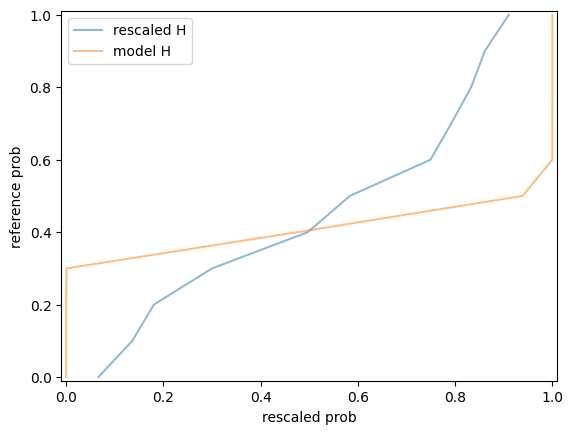

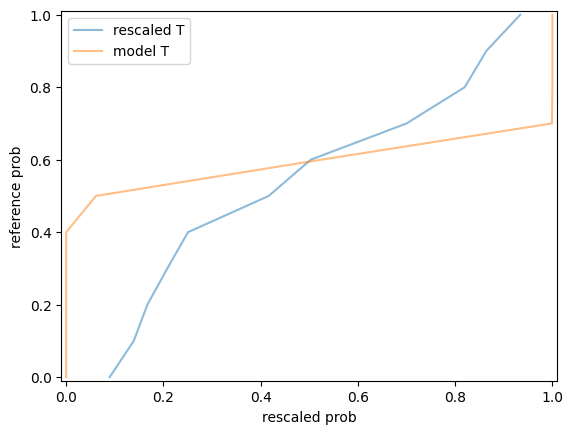

In [27]:
model_ps, reference_ps = [], []
for i, d in enumerate(actual_data): 
    model_ps.append(d)
    reference_ps.append(expected_data[i])

rescaled_ps, _ = rescale_prob(model_ps, reference_ps)


plt.xlim([-0.01,1.01])
plt.ylim([-0.01,1.01])
plt.xlabel('rescaled prob')
plt.ylabel('reference prob')
# print(model_ps, reference_ps, rescaled_ps)
rescale_p_h = np.array(rescaled_ps)[:, 0]
reference_p_h  = np.array(reference_ps)[:, 0]
model_p_h  = np.array(model_ps)[:, 0]

rescale_p_t = np.array(rescaled_ps)[:, 1]
reference_p_t  = np.array(reference_ps)[:, 1]
model_p_t  = np.array(model_ps)[:, 1]

plt.plot(rescale_p_h, reference_p_h, alpha=0.5, label='rescaled H')
plt.plot(model_p_h, reference_p_h, alpha=0.5, label='model H')
plt.legend()
plt.show()


plt.xlim([-0.01,1.01])
plt.ylim([-0.01,1.01])
plt.xlabel('rescaled prob')
plt.ylabel('reference prob')
plt.plot(rescale_p_t, reference_p_t, alpha=0.5, label='rescaled T')
plt.plot(model_p_t, reference_p_t, alpha=0.5, label='model T')
# TO DO dashed, compute ECE measure (deviation from y=x), to show temp scaled log prob is still worse that seq 
plt.legend()
plt.show()


In [7]:
# Setting font sizes
plt.rcParams.update({
    'font.size': 14,          # Default text size
    'axes.titlesize': 16,     # Axes title size
    'axes.labelsize': 16,     # Axes label size
    'xtick.labelsize': 14,    # X-tick label size
    'ytick.labelsize': 14,    # Y-tick label size
    'legend.fontsize': 14,    # Legend font size
    'figure.titlesize': 18    # Figure title size
})

NameError: name 'rescale_p_h' is not defined

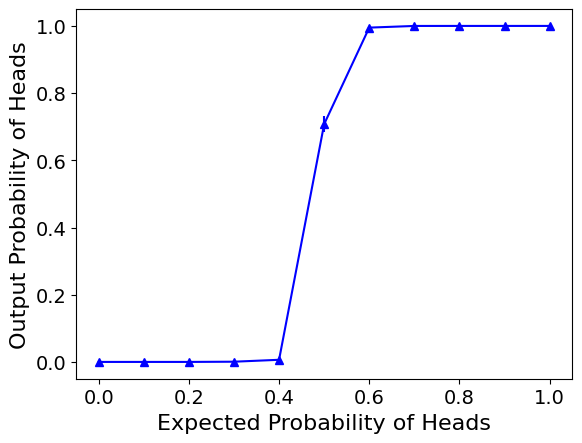

In [8]:
key_to_color= {'h': 'b', 't': 'g'}
key_to_name = {'h': 'Heads', 't': 'Tails'}

path = '/Users/nicolemeister/Desktop/STANFORD/distributions/results/biased_coin/'

model='gpt-4'  # load data

with open(path + model + '/biased_coin_benchmark.json', 'r') as file:
  # Load JSON data into a dictionary
  data = json.load(file)

expected, actual_all, expected_all, actual_mean, actual_std = defaultdict(list), defaultdict(list), defaultdict(list), defaultdict(list), defaultdict(list)

for i, question in enumerate(list(data.keys())):
  if i%2==1:

    expected_results = data[question]['expected_results']
    actual_results = data[question]['actual_results']
    
    avg_expected_results = data[question]['avg_expected_results']
    std_expected_results = data[question]['std_expected_results']

    # if actual results has any [], fill it with zeros 
    for key in list(actual_results.keys()):
      if not actual_results[key]:
          actual_results[key] = list(np.zeros(5))
          avg_expected_results[key] = 0
          std_expected_results[key] = 0
    # Expand expected results to the size of actual results 
    for key in list(expected_results.keys()):
      expected_results[key] = list(expected_results[key] * np.ones(len(actual_results[key])))
    
    for key in list(expected_results.keys()):
      expected_all[key]+=expected_results[key]
      actual_all[key]+=actual_results[key]

      expected[key].append(expected_results[key][0])
      actual_mean[key].append(avg_expected_results[key])
      actual_std[key].append(std_expected_results[key])

# plt.figure(figsize=(20, 12))  # Double the size of the figure

for key in list(expected_results.keys())[0]:
    plt.plot(expected[key], actual_mean[key], label=key_to_name[key], color=key_to_color[key])
    plt.errorbar(expected[key], actual_mean[key], actual_std[key], linestyle='None', color=key_to_color[key], marker='^')
    plt.xlabel("Expected Probability of Heads")
    plt.ylabel("Output Probability of Heads")

plt.plot(expected[key], rescale_p_h[::-1], label="Heads (TS)", color='green', alpha=0.5)
plt.errorbar(expected[key], rescale_p_h[::-1], np.zeros(len(rescale_p_h)), linestyle='None', color='green', marker='^', alpha=0.5)

plt.legend()
x = np.linspace(0, 1, 100)
# Plot y=x as a red dashed line
plt.plot(x, x, 'r--', label='y=x', alpha=0.5)
plt.savefig('/Users/nicolemeister/Desktop/STANFORD/distributions/figures/biased_coinflip/model_logprob.pdf')
plt.show()


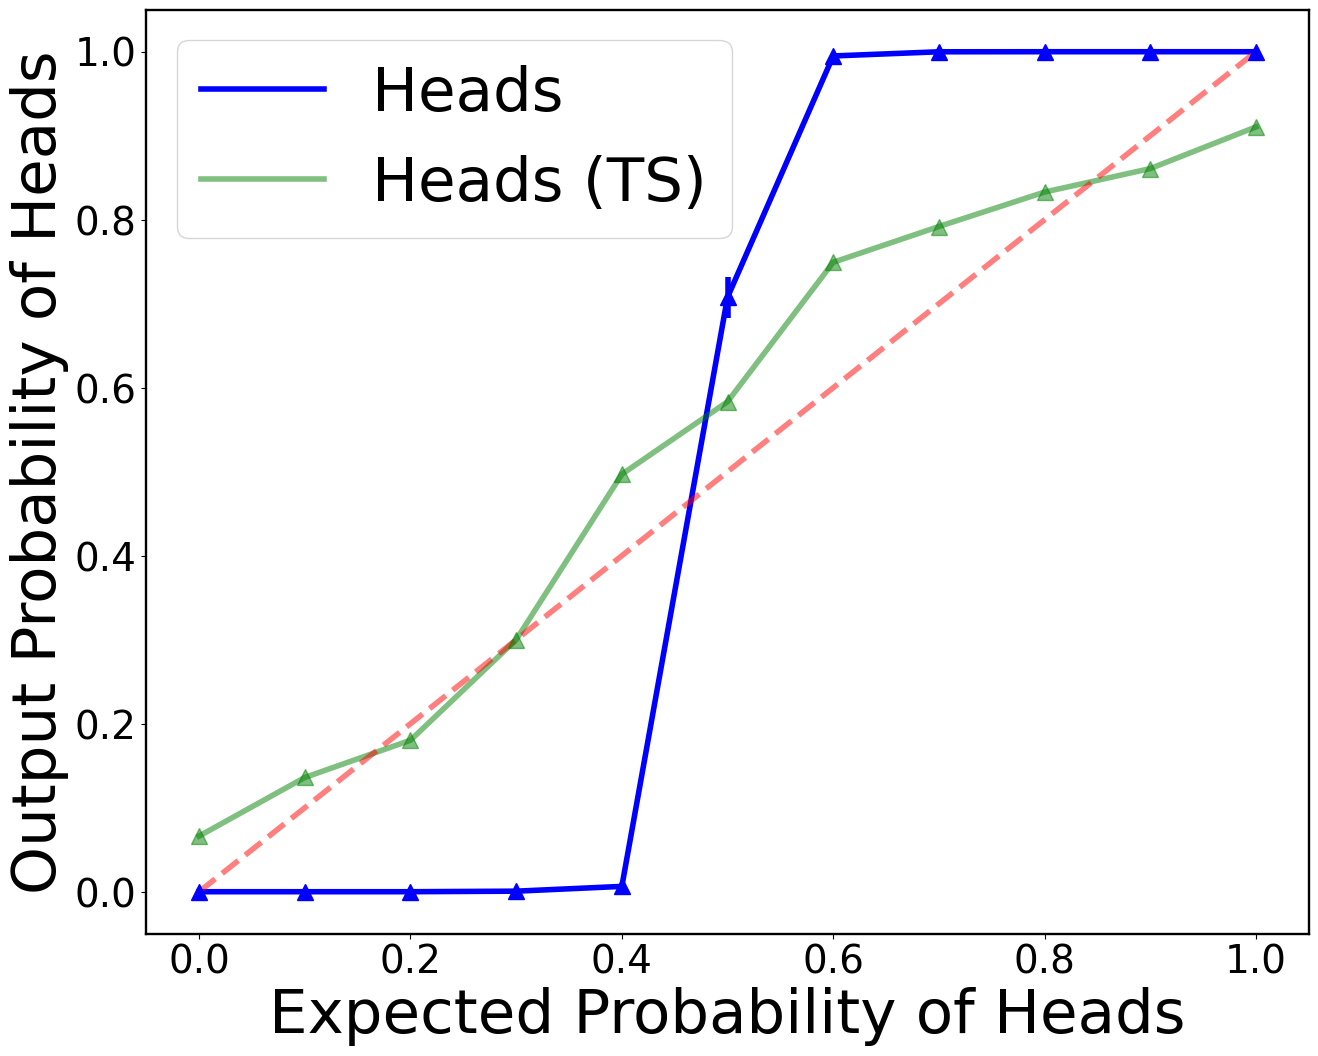

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import json
from collections import defaultdict

# Setting font sizes and scaling other parameters
scale_factor = 2
plt.rcParams.update({
    'font.size': 18 * scale_factor,          # Default text size
    'axes.titlesize': 16 * scale_factor,     # Axes title size
    'axes.labelsize': 22 * scale_factor,     # Axes label size
    'xtick.labelsize': 14 * scale_factor,    # X-tick label size
    'ytick.labelsize': 14 * scale_factor,    # Y-tick label size
    'legend.fontsize': 22 * scale_factor,    # Legend font size
    'figure.titlesize': 18 * scale_factor    # Figure title size
})

key_to_color= {'h': 'b', 't': 'g'}
key_to_name = {'h': 'Heads', 't': 'Tails'}

path = '/Users/nicolemeister/Desktop/STANFORD/distributions/results/biased_coin/'

model='gpt-4'  # load data

with open(path + model + '/biased_coin_benchmark.json', 'r') as file:
  # Load JSON data into a dictionary
  data = json.load(file)

expected, actual_all, expected_all, actual_mean, actual_std = defaultdict(list), defaultdict(list), defaultdict(list), defaultdict(list), defaultdict(list)

for i, question in enumerate(list(data.keys())):
  if i % 2 == 1:
    expected_results = data[question]['expected_results']
    actual_results = data[question]['actual_results']
    
    avg_expected_results = data[question]['avg_expected_results']
    std_expected_results = data[question]['std_expected_results']

    # if actual results has any [], fill it with zeros 
    for key in list(actual_results.keys()):
      if not actual_results[key]:
          actual_results[key] = list(np.zeros(5))
          avg_expected_results[key] = 0
          std_expected_results[key] = 0
    # Expand expected results to the size of actual results 
    for key in list(expected_results.keys()):
      expected_results[key] = list(expected_results[key] * np.ones(len(actual_results[key])))
    
    for key in list(expected_results.keys()):
      expected_all[key] += expected_results[key]
      actual_all[key] += actual_results[key]

      expected[key].append(expected_results[key][0])
      actual_mean[key].append(avg_expected_results[key])
      actual_std[key].append(std_expected_results[key])

plt.figure(figsize=(15, 12))  # Double the size of the figure

for key in list(expected_results.keys())[0]:
    plt.plot(expected[key], actual_mean[key], label=key_to_name[key], color=key_to_color[key], markersize=6 * scale_factor, linewidth=2 * scale_factor)
    plt.errorbar(expected[key], actual_mean[key], actual_std[key], linestyle='None', color=key_to_color[key], marker='^', markersize=6 * scale_factor, linewidth=2 * scale_factor)
    plt.xlabel("Expected Probability of Heads")
    plt.ylabel("Output Probability of Heads")

# Assuming rescale_p_h is defined somewhere in your code
plt.plot(expected[key], rescale_p_h[::-1], label="Heads (TS)", color='green', alpha=0.5, markersize=6 * scale_factor, linewidth=2 * scale_factor)
plt.errorbar(expected[key], rescale_p_h[::-1], np.zeros(len(rescale_p_h)), linestyle='None', color='green', marker='^', alpha=0.5, markersize=6 * scale_factor, linewidth=2 * scale_factor)

plt.legend()
x = np.linspace(0, 1, 100)
plt.plot(x, x, 'r--', label='y=x', alpha=0.5, linewidth=2 * scale_factor)

# Change the plot bounding box thickness
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(0.85*scale_factor)



plt.savefig('/Users/nicolemeister/Desktop/STANFORD/distributions/figures/biased_coinflip/model_logprob.svg')

plt.show()


#### Survey Question

In [25]:
# Specify the file name
filename = '/Users/nicolemeister/Desktop/STANFORD/distributions/results/opinionqa/model_logprobs/gpt-4/task1/Pew_American_Trends_Panel_disagreement_100/POLPARTY/Democrat.json'

# Read data from a JSON file
with open(file_name, 'r') as json_file:
    dem_data = json.load(json_file)


In [26]:
model_ps, reference_ps = [], []
for i, qID in enumerate(dem_data): 
    model_ps.append(list(dem_data[qID]['avg_actual_results'].values()))
    reference_ps.append(list(dem_data[qID]['expected_results'].values()))

rescaled_ps, _ = rescale_prob(model_ps, reference_ps)

6.968628825478804


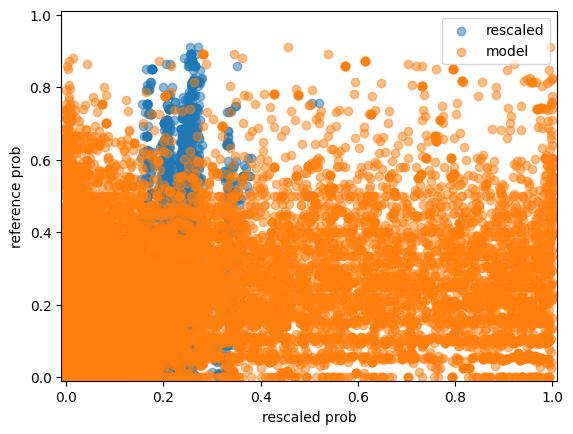

In [11]:
plt.xlim([-0.01,1.01])
plt.ylim([-0.01,1.01])
plt.xlabel('rescaled prob')
plt.ylabel('reference prob')

rescaled_ps_plot, reference_ps_plot, model_ps_plot = [], [], []
for i, rescaled_p in enumerate(rescaled_ps):
    for j, p in enumerate(rescaled_p):
        rescaled_ps_plot.append(p)
        reference_ps_plot.append(reference_ps[i][j])
        model_ps_plot.append(model_ps[i][j])

plt.scatter(rescaled_ps_plot, reference_ps_plot, alpha=0.5, label='rescaled')
plt.scatter(model_ps_plot, reference_ps_plot, alpha=0.5, label='model')
plt.legend()
plt.show()

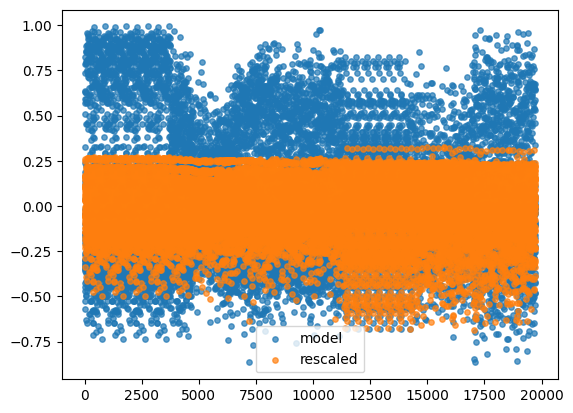

In [13]:
count=0
diff_model = [a - b for a, b in zip(model_ps_plot, reference_ps_plot)]
diff_rescaled = [a - b for a, b in zip(rescaled_ps_plot, reference_ps_plot)]
plt.scatter(np.arange(len(diff_model)), diff_model, s=15, alpha=0.7, label='model')
plt.scatter(np.arange(len(diff_rescaled)), diff_rescaled, s=15, alpha=0.7, label='rescaled')
plt.legend()
plt.show()

In [48]:
dem_data

[[0.9999999303752514, 6.847161279653394e-09],
 [0.9999987812365528, 3.837454635106839e-07],
 [0.999997255433026, 2.2136310542628543e-06],
 [0.9999801039547075, 1.9742396192692357e-05],
 [0.9998596927761702, 0.0001398520553369645],
 [0.9386770687238686, 0.06132286830705917],
 [0.47536972347003237, 0.5246302273272766],
 [0.0010397995854631663, 0.9989601983543173],
 [4.685448224396325e-06, 0.9999952706721971],
 [3.101818887950527e-07, 0.9999996560362898],
 [4.851408696436707e-10, 1.0000000038215786]]

In [31]:
## Survey question temp scaling, one tau per dataset + per steering method
# one tau per model 
# iterate through each model and steering method
import os
dataset_to_demgroup = {'opinionqa': ['POLPARTY', 'SEX', 'RACE'], 'nytimes': ['POLPARTY', 'SEX'] }
dem_group_to_dem_mapping = {'POLPARTY': ['Democrat', 'Republican'],
                            'SEX': ['Male', 'Female'],
                            'RACE': ['Black', 'White']}

# for dataset in ['nytimes', 'opinionqa']:
for model in ['llama3-70b', 'gpt-4', 'gpt-3.5-turbo-0125']:
    # FIND THE OPTIMAL TEMPERATURE
    model_ps, reference_ps = [], []
    for dataset in ['nytimes', 'opinionqa']:
        for steering_method in ['task0', 'task1', 'task3_easy_hard']:
            for dem_group in dataset_to_demgroup[dataset]:
                for dem in dem_group_to_dem_mapping[dem_group]:
                    
                    if steering_method=='task0':
                        dem_group = 'NONE'
                        dem='Democrat'
                        expected_results_str='expected_results_POLPARTY_Democrat'

                    else: expected_results_str='expected_results'
                    
                    if dataset=='opinionqa': wave='Pew_American_Trends_Panel_disagreement_100'
                    else: wave=''

                    print(steering_method, model, dem_group, dem)

                    file_name = '/Users/nicolemeister/Desktop/STANFORD/distributions/results/{}/model_logprobs/{}/{}/{}/{}/{}.json'.format(dataset,model,steering_method, wave, dem_group, dem)

                    # Read data from a JSON file
                    with open(file_name, 'r') as json_file:
                        dem_data = json.load(json_file)
                    
                    print(len(dem_data.keys()))
                    for i, qID in enumerate(dem_data): 
                        model_ps.append(list(dem_data[qID]['avg_actual_results'].values()))
                        reference_ps.append(list(dem_data[qID][expected_results_str].values()))

    rescaled_ps, _ = rescale_prob(model_ps, reference_ps)

    count_2=0
    for dataset in ['nytimes', 'opinionqa']:
        for steering_method in ['task0', 'task1', 'task3_easy_hard']:
            for dem_group in dataset_to_demgroup[dataset]:
                for dem in dem_group_to_dem_mapping[dem_group]:
                    if steering_method=='task0':
                        dem_group = 'NONE'
                        dem='Democrat'
                        expected_results_str='expected_results_POLPARTY_Democrat'

                    else: expected_results_str='expected_results'
                    if dataset=='opinionqa': wave='Pew_American_Trends_Panel_disagreement_100'
                    else: wave=''

                    file_name = '/Users/nicolemeister/Desktop/STANFORD/distributions/results/{}/model_logprobs/{}/{}/{}/{}/{}.json'.format(dataset,model,steering_method, wave, dem_group, dem)

                    # Read data from a JSON file
                    with open(file_name, 'r') as json_file:
                        dem_data = json.load(json_file)

                    # write a new dictionary that has the rescaled probs
                    for i, qID in enumerate(dem_data):    
                        dem_data[qID]['avg_actual_results'] = dict(zip(list(dem_data[qID]['avg_actual_results'].keys()), rescaled_ps[count_2]))
                        count_2+=1
                
                    rescaled_filename = file_name.split('model_logprobs')[0]+'rescaled_model_logprobs'+file_name.split('model_logprobs')[1]
                    
                    if not os.path.exists(file_name.split('model_logprobs')[0]+'rescaled_model_logprobs/' + model): os.makedirs(file_name.split('model_logprobs')[0]+'rescaled_model_logprobs/'+model, exist_ok=True)
                    if not os.path.exists(file_name.split('model_logprobs')[0]+'rescaled_model_logprobs/' + model+'/'+steering_method): os.makedirs(file_name.split('model_logprobs')[0]+'rescaled_model_logprobs/'+model+'/'+steering_method, exist_ok=True) 
                    if not os.path.exists(file_name.split('model_logprobs')[0]+'rescaled_model_logprobs/' + model+'/'+steering_method+'/'+wave): os.makedirs(file_name.split('model_logprobs')[0]+'rescaled_model_logprobs/'+model+'/'+steering_method+'/'+wave, exist_ok=True)
                    if not os.path.exists(file_name.split('model_logprobs')[0]+'rescaled_model_logprobs/' + model+'/'+steering_method+'/'+wave+'/'+dem_group): os.makedirs(file_name.split('model_logprobs')[0]+'rescaled_model_logprobs/'+model+'/'+steering_method+'/'+wave+'/'+dem_group, exist_ok=True)
                    
                    with open(rescaled_filename, 'w') as json_file:
                        json.dump(dem_data, json_file)x


task0 llama3-70b NONE Democrat
235
task0 llama3-70b NONE Democrat
235
task0 llama3-70b NONE Democrat
235
task0 llama3-70b NONE Democrat
235
task1 llama3-70b POLPARTY Democrat
235
task1 llama3-70b POLPARTY Republican
235
task1 llama3-70b SEX Male
235
task1 llama3-70b SEX Female
235
task3_easy_hard llama3-70b POLPARTY Democrat
235
task3_easy_hard llama3-70b POLPARTY Republican
235
task3_easy_hard llama3-70b SEX Male
235
task3_easy_hard llama3-70b SEX Female
235
task0 llama3-70b NONE Democrat
100
task0 llama3-70b NONE Democrat
100
task0 llama3-70b NONE Democrat
100
task0 llama3-70b NONE Democrat
100
task0 llama3-70b NONE Democrat
100
task0 llama3-70b NONE Democrat
100
task1 llama3-70b POLPARTY Democrat
100
task1 llama3-70b POLPARTY Republican
100
task1 llama3-70b SEX Male
100
task1 llama3-70b SEX Female
100
task1 llama3-70b RACE Black
100
task1 llama3-70b RACE White
100
task3_easy_hard llama3-70b POLPARTY Democrat
100
task3_easy_hard llama3-70b POLPARTY Republican
100
task3_easy_hard llam

/var/folders/_r/w12mdwc56wb9k_g0q82pk8400000gn/T/ipykernel_35302/2753123598.py:8: RuntimeWarning: invalid value encountered in divide
  p=p/np.sum(p) # normalize!


sum(p): 0.0
[] 3635 []
sum(q): 0.0
[] 3635 []
sum(p): nan
[nan nan nan nan nan nan] 3778 [0, 0, 0, 0, 0, 0]
sum(p): nan
[nan nan nan nan nan] 3791 [0, 0, 0, 0, 0]
sum(p): 0.0
[] 4235 []
sum(q): 0.0
[] 4235 []
sum(p): 0.0
[] 3635 []
sum(q): 0.0
[] 3635 []
sum(p): nan
[nan nan nan nan nan nan] 3778 [0, 0, 0, 0, 0, 0]
sum(p): nan
[nan nan nan nan nan] 3791 [0, 0, 0, 0, 0]
sum(p): 0.0
[] 4235 []
sum(q): 0.0
[] 4235 []
sum(p): 0.0
[] 3635 []
sum(q): 0.0
[] 3635 []
sum(p): nan
[nan nan nan nan nan nan] 3778 [0, 0, 0, 0, 0, 0]
sum(p): nan
[nan nan nan nan nan] 3791 [0, 0, 0, 0, 0]
sum(p): 0.0
[] 4235 []
sum(q): 0.0
[] 4235 []
sum(p): 0.0
[] 3635 []
sum(q): 0.0
[] 3635 []
sum(p): nan
[nan nan nan nan nan nan] 3778 [0, 0, 0, 0, 0, 0]
sum(p): nan
[nan nan nan nan nan] 3791 [0, 0, 0, 0, 0]
sum(p): 0.0
[] 4235 []
sum(q): 0.0
[] 4235 []
sum(p): 0.0
[] 3635 []
sum(q): 0.0
[] 3635 []
sum(p): nan
[nan nan nan nan nan nan] 3778 [0, 0, 0, 0, 0, 0]
sum(p): nan
[nan nan nan nan nan] 3791 [0, 0, 0, 0, 0]
s

/var/folders/_r/w12mdwc56wb9k_g0q82pk8400000gn/T/ipykernel_35302/2753123598.py:28: RuntimeWarning: invalid value encountered in divide
  scaled.append(scaled_p/np.sum(scaled_p))


In [32]:
## Survey question temp scaling, one tau per dataset + per steering method
# one tau per model 
# iterate through each model and steering method
import os
dataset_to_demgroup = {'opinionqa': ['POLPARTY', 'SEX', 'RACE'], 'nytimes': ['POLPARTY', 'SEX'] }
dem_group_to_dem_mapping = {'POLPARTY': ['Democrat', 'Republican'],
                            'SEX': ['Male', 'Female'],
                            'RACE': ['Black', 'White']}

# for dataset in ['nytimes', 'opinionqa']:
for model in ['llama3-70b', 'gpt-4', 'gpt-3.5-turbo-0125']:
    # FIND THE OPTIMAL TEMPERATURE
    for dataset in ['nytimes', 'opinionqa']:
        for steering_method in ['task0', 'task1', 'task3_easy_hard']:
            model_ps, reference_ps = [], []
            for dem_group in dataset_to_demgroup[dataset]:
                for dem in dem_group_to_dem_mapping[dem_group]:
                    
                    if steering_method=='task0':
                        dem_group = 'NONE'
                        dem='Democrat'
                        expected_results_str='expected_results_POLPARTY_Democrat'

                    else: expected_results_str='expected_results'
                    
                    if dataset=='opinionqa': wave='Pew_American_Trends_Panel_disagreement_100'
                    else: wave=''

                    #print(steering_method, model, dem_group, dem)

                    file_name = '/Users/nicolemeister/Desktop/STANFORD/distributions/results/{}/model_logprobs/{}/{}/{}/{}/{}.json'.format(dataset,model,steering_method, wave, dem_group, dem)

                    # Read data from a JSON file
                    with open(file_name, 'r') as json_file:
                        dem_data = json.load(json_file)
                    
                    #print(len(dem_data.keys()))
                    for i, qID in enumerate(dem_data): 
                        model_ps.append(list(dem_data[qID]['avg_actual_results'].values()))
                        reference_ps.append(list(dem_data[qID][expected_results_str].values()))

            rescaled_ps, _ = rescale_prob(model_ps, reference_ps)

            count_2=0
            for dem_group in dataset_to_demgroup[dataset]:
                for dem in dem_group_to_dem_mapping[dem_group]:
                    if steering_method=='task0':
                        dem_group = 'NONE'
                        dem='Democrat'
                        expected_results_str='expected_results_POLPARTY_Democrat'

                    else: expected_results_str='expected_results'
                    if dataset=='opinionqa': wave='Pew_American_Trends_Panel_disagreement_100'
                    else: wave=''

                    file_name = '/Users/nicolemeister/Desktop/STANFORD/distributions/results/{}/model_logprobs/{}/{}/{}/{}/{}.json'.format(dataset,model,steering_method, wave, dem_group, dem)

                    # Read data from a JSON file
                    with open(file_name, 'r') as json_file:
                        dem_data = json.load(json_file)

                    # write a new dictionary that has the rescaled probs
                    for i, qID in enumerate(dem_data):    
                        dem_data[qID]['avg_actual_results'] = dict(zip(list(dem_data[qID]['avg_actual_results'].keys()), rescaled_ps[count_2]))
                        count_2+=1
                    
                    rescaled_filename = file_name.split('model_logprobs')[0]+'rescaled_model_logprobs'+file_name.split('model_logprobs')[1]
                    
                    if not os.path.exists(file_name.split('model_logprobs')[0]+'rescaled_model_logprobs/' + model): os.makedirs(file_name.split('model_logprobs')[0]+'rescaled_model_logprobs/'+model, exist_ok=True)
                    if not os.path.exists(file_name.split('model_logprobs')[0]+'rescaled_model_logprobs/' + model+'/'+steering_method): os.makedirs(file_name.split('model_logprobs')[0]+'rescaled_model_logprobs/'+model+'/'+steering_method, exist_ok=True) 
                    if not os.path.exists(file_name.split('model_logprobs')[0]+'rescaled_model_logprobs/' + model+'/'+steering_method+'/'+wave): os.makedirs(file_name.split('model_logprobs')[0]+'rescaled_model_logprobs/'+model+'/'+steering_method+'/'+wave, exist_ok=True)
                    if not os.path.exists(file_name.split('model_logprobs')[0]+'rescaled_model_logprobs/' + model+'/'+steering_method+'/'+wave+'/'+dem_group): os.makedirs(file_name.split('model_logprobs')[0]+'rescaled_model_logprobs/'+model+'/'+steering_method+'/'+wave+'/'+dem_group, exist_ok=True)
                    
                    with open(rescaled_filename, 'w') as json_file:
                        json.dump(dem_data, json_file)


4.999994379154743
4.999994139028055
4.999994043998623
4.9999951723584495
sum(p): 0.0
[] 215 []
sum(q): 0.0
[] 215 []
sum(p): 0.0
[] 215 []
sum(q): 0.0
[] 215 []
sum(p): 0.0
[] 215 []
sum(q): 0.0
[] 215 []
sum(p): 0.0
[] 215 []
sum(q): 0.0
[] 215 []
sum(p): 0.0
[] 215 []
sum(q): 0.0
[] 215 []
sum(p): 0.0
[] 215 []
sum(q): 0.0
[] 215 []
sum(p): 0.0
[] 215 []
sum(q): 0.0
[] 215 []
sum(p): 0.0
[] 215 []
sum(q): 0.0
[] 215 []
sum(p): 0.0
[] 215 []
sum(q): 0.0
[] 215 []
sum(p): 0.0
[] 215 []
sum(q): 0.0
[] 215 []
sum(p): 0.0
[] 215 []
sum(q): 0.0
[] 215 []
sum(p): 0.0
[] 215 []
sum(q): 0.0
[] 215 []
sum(p): 0.0
[] 215 []
sum(q): 0.0
[] 215 []
sum(p): 0.0
[] 215 []
sum(q): 0.0
[] 215 []
sum(p): 0.0
[] 215 []
sum(q): 0.0
[] 215 []
sum(p): 0.0
[] 215 []
sum(q): 0.0
[] 215 []
sum(p): 0.0
[] 215 []
sum(q): 0.0
[] 215 []
sum(p): 0.0
[] 215 []
sum(q): 0.0
[] 215 []
sum(p): 0.0
[] 215 []
sum(q): 0.0
[] 215 []
sum(p): 0.0
[] 215 []
sum(q): 0.0
[] 215 []
sum(p): 0.0
[] 215 []
sum(q): 0.0
[] 215 []
sum

/var/folders/_r/w12mdwc56wb9k_g0q82pk8400000gn/T/ipykernel_35302/2753123598.py:8: RuntimeWarning: invalid value encountered in divide
  p=p/np.sum(p) # normalize!


sum(p): nan
[nan nan nan nan nan nan] 358 [0, 0, 0, 0, 0, 0]
sum(p): nan
[nan nan nan nan nan] 371 [0, 0, 0, 0, 0]
sum(p): 0.0
[] 215 []
sum(q): 0.0
[] 215 []
sum(p): nan
[nan nan nan nan nan nan] 358 [0, 0, 0, 0, 0, 0]
sum(p): nan
[nan nan nan nan nan] 371 [0, 0, 0, 0, 0]
sum(p): 0.0
[] 215 []
sum(q): 0.0
[] 215 []
sum(p): nan
[nan nan nan nan nan nan] 358 [0, 0, 0, 0, 0, 0]
sum(p): nan
[nan nan nan nan nan] 371 [0, 0, 0, 0, 0]
sum(p): 0.0
[] 215 []
sum(q): 0.0
[] 215 []
sum(p): nan
[nan nan nan nan nan nan] 358 [0, 0, 0, 0, 0, 0]
sum(p): nan
[nan nan nan nan nan] 371 [0, 0, 0, 0, 0]
sum(p): 0.0
[] 215 []
sum(q): 0.0
[] 215 []
sum(p): nan
[nan nan nan nan nan nan] 358 [0, 0, 0, 0, 0, 0]
sum(p): nan
[nan nan nan nan nan] 371 [0, 0, 0, 0, 0]
sum(p): 0.0
[] 215 []
sum(q): 0.0
[] 215 []
sum(p): nan
[nan nan nan nan nan nan] 358 [0, 0, 0, 0, 0, 0]
sum(p): nan
[nan nan nan nan nan] 371 [0, 0, 0, 0, 0]
sum(p): 0.0
[] 215 []
sum(q): 0.0
[] 215 []
sum(p): nan
[nan nan nan nan nan nan] 358 [0, 

/var/folders/_r/w12mdwc56wb9k_g0q82pk8400000gn/T/ipykernel_35302/2753123598.py:28: RuntimeWarning: invalid value encountered in divide
  scaled.append(scaled_p/np.sum(scaled_p))


sum(p): 0.0
[] 215 []
sum(q): 0.0
[] 215 []
sum(p): 0.0
[] 215 []
sum(q): 0.0
[] 215 []
sum(p): 0.0
[] 215 []
sum(q): 0.0
[] 215 []
sum(p): 0.0
[] 215 []
sum(q): 0.0
[] 215 []
sum(p): 0.0
[] 215 []
sum(q): 0.0
[] 215 []
sum(p): 0.0
[] 215 []
sum(q): 0.0
[] 215 []
sum(p): 0.0
[] 215 []
sum(q): 0.0
[] 215 []
sum(p): 0.0
[] 215 []
sum(q): 0.0
[] 215 []
sum(p): 0.0
[] 215 []
sum(q): 0.0
[] 215 []
sum(p): 0.0
[] 215 []
sum(q): 0.0
[] 215 []
sum(p): 0.0
[] 215 []
sum(q): 0.0
[] 215 []
sum(p): 0.0
[] 215 []
sum(q): 0.0
[] 215 []
sum(p): 0.0
[] 215 []
sum(q): 0.0
[] 215 []
sum(p): 0.0
[] 215 []
sum(q): 0.0
[] 215 []
sum(p): 0.0
[] 215 []
sum(q): 0.0
[] 215 []
sum(p): 0.0
[] 215 []
sum(q): 0.0
[] 215 []
sum(p): 0.0
[] 215 []
sum(q): 0.0
[] 215 []
sum(p): 0.0
[] 215 []
sum(q): 0.0
[] 215 []
sum(p): 0.0
[] 215 []
sum(q): 0.0
[] 215 []
sum(p): 0.0
[] 215 []
sum(q): 0.0
[] 215 []
sum(p): 0.0
[] 215 []
sum(q): 0.0
[] 215 []
sum(p): 0.0
[] 215 []
sum(q): 0.0
[] 215 []
sum(p): 0.0
[] 215 []
sum(q): 0.